In [ ]:
#1 import libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2

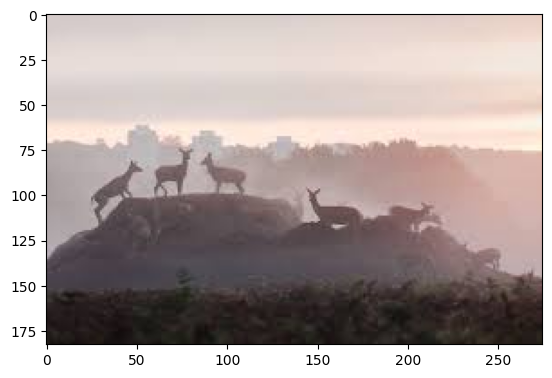

In [ ]:
import cv2
#2 load your image (convert the img into rgb if its in brg)
img = cv2.imread('/content/drive/MyDrive/Computer Vision Labs/colorgrading.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)



In [ ]:
#def function for colorgrading "warm filter"
def apply_warm_filter(image):

  #we split the image in r,g,b using cv2.split
  res_r, res_g, res_b = cv2.split(image)

   #now we increase  red and green to create yellow/warm tint
   #we use cv2.addweight or lookup tables to prevent wrapping(overflow)

  res_r =cv2.LUT(res_r,np.array([min(255,i*1.1)for i in range(256)])).astype(('uint8'))
  res_b = cv2.LUT(res_b, np.array([max(0, i * 0.9) for i in range(256)]).astype('uint8'))

  return cv2.merge((res_r, res_g, res_b))



In [ ]:
#def function for colorgrading "cool filter"
def apply_cool_filter(image):

  #we split the image in r,g,b using cv2.split
  res_r, res_b, res_g = cv2.split(image)

  #now we basically decrease red  to remove 'warmth'

  res_r = cv2.LUT(res_r, np.array([max(0, i * 0.8) for i in range(256)]).astype('uint8'))

  #same for greem to remove little bit yelowing
  res_g = cv2.LUT(res_g, np.array([max(0, i * 0.9) for i in range(256)]).astype('uint8'))

  #now we increase blue to add "cooling"
  res_b = cv2.LUT(res_b, np.array([min(255, i * 1.2) for i in range(256)]).astype('uint8'))

  return cv2.merge((res_r, res_g, res_b))



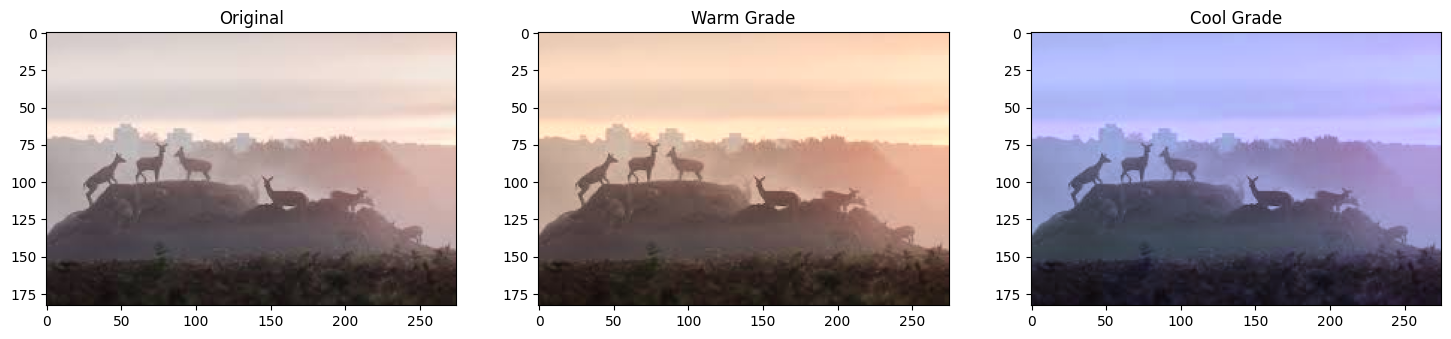

In [ ]:
w_graded_img = apply_warm_filter(img_rgb)
c_graded_img = apply_cool_filter(img_rgb)

plt.figure(figsize=(18, 6)) # Adjusted figure size to accommodate 3 plots
plt.subplot(1, 3, 1); plt.imshow(img_rgb); plt.title("Original")
plt.subplot(1, 3, 2); plt.imshow(w_graded_img); plt.title("Warm Grade")
plt.subplot(1, 3, 3); plt.imshow(c_graded_img); plt.title("Cool Grade")
plt.show()